# Import libraries

In [1]:
import tensorflow as tf
import os
from tensorflow.keras.layers import Conv2D , MaxPooling2D , Dropout , Flatten , Dense ,BatchNormalization,Input,ReLU,LeakyReLU,AveragePooling2D,MultiHeadAttention,SeparableConv2D,SpatialDropout2D,GlobalAveragePooling2D,Lambda,Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint , EarlyStopping ,ReduceLROnPlateau
from tensorflow.keras import models , optimizers , regularizers
from tensorflow.keras.applications.resnet import ResNet50, preprocess_input
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential


## Load the training and test datsets

In [2]:
# Load train csv

df_train = pd.read_csv('/kaggle/input/ai-vs-human-generated-dataset/train.csv')

In [3]:
#Load test csv
df_test = pd.read_csv('/kaggle/input/ai-vs-human-generated-dataset/test.csv')

In [4]:
df_train.head()

,Unnamed: 0,file_name,label
0,0,train_data/a6dcb93f596a43249135678dfcfc17ea.jpg,1
1,1,train_data/041be3153810433ab146bc97d5af505c.jpg,0
2,2,train_data/615df26ce9494e5db2f70e57ce7a3a4f.jpg,1
3,3,train_data/8542fe161d9147be8e835e50c0de39cd.jpg,0
4,4,train_data/5d81fa12bc3b4cea8c94a6700a477cf2.jpg,1


# Clean data

In [5]:
class Clean():
    
    """This class is responsible for data cleaning and examines and performs the necessary processes 
    for handling duplicates, null values, data type changes, and column removal.
 
   

    """

    def __init__(self,df):

        self.df = pd.DataFrame(df)
    
    def eraseColumns (self,columns):
        """This function receives a list of the names of the columns to be deleted.
        Parameters:
        columns (list): List of column names to be deleted.
    
        Returns:
        pd.DataFrame: The DataFrame with the specified columns removed.
        str: Error message if the input is invalid or columns do not exist.
        """

        # check if the parameter is not a list
        if not isinstance(columns, list):
            raise ValueError("Error: The parameter 'columns' must be a list.")
        
        # check if the DataFrame has the especifed columns
        missing_columns = [col for col in columns if col not in self.df.columns]
        if missing_columns:
            raise ValueError( f"Error: The following columns do not exist in the DataFrame: {missing_columns}")

        try:

            self.df.drop(columns=columns,inplace=True)
            
            return self.df
            
        except Exception as e:
            
            return f"An error occurred while deleting columns: {str(e)}"

    def duplicated (self):
        
        # Check if there are duplicated rows
        if self.df.duplicated().sum() > 0:

            try:
                    self.df.drop_duplicates().reset_index(drop=True)
                    print('Duplicated rows eliminated successfully')

                    return self.df
            
            except Exception as e:
            
                return f"An error occurred while deleting rows: {str(e)}"

        else:
            print('There are not duplicated rows')
            return self.df


    def nullData(self):

        #Check if there are null data
        if self.df.isnull().sum().sum() > 0:

            try:
                self.df.dropna().reset_index(drop=True)
                print('Duplicated rows eliminated successfully')
                return self.df

            except Exception as e:
            
                return f"An error occurred while deleting rows: {str(e)}"
            
        else:
             print('There are not null rows')
             return self.df

    @staticmethod

    def changeType(df,dictionary):
        """This change the type of data of the columns

        Parameters:
        dictionary (dict): Dictionary where the key is the name of the column ande value the type of data to change
    
        Returns:
        pd.DataFrame: The DataFrame with the specified columns change.
        str: Error message if the input is invalid or columns do not exist.
           """

        if isinstance(dictionary, dict):

            for key , value in dictionary.items():
                
                df[key] = df[key].astype(value)
                print(f'The column {key} was successfully change to {value}')
            return df
            
        else:
                raise ValueError( "The type of data of th parameter is not correct.It mus be dict")
            
        

            
        


        

In [6]:
def orchestrator( steps):
    """
    Orchestrator that executes a series of steps (functions) in order.
    If a step fails, it logs the error and continues with the next step.
    At the end, it displays a summary of the errors that occurred
    
    Parameters:
        df (pd.DataFrame): The DataFrame to process.
        steps (list): List of tuples containing the function and its arguments.
    
    Returns:
        pd.DataFrame: The processed DataFrame.
    """
    errors = []  # list of errors

    for step in steps:
        func, args = step[0], step[1:]
        print(f"Executing: {func.__name__} with args: {args}")
        try:
            df = func(*args)  # Execute the function with its arguments 
        except Exception as e:
            # Catch the error and save in the errors list
            errors.append({
                'function': func.__name__,
                'args': args,
                'error': str(e)
            })
            print(f"Error in {func.__name__}: {str(e)}")
        else:
            print(f"{func.__name__} completed successfully.")

    # Show th resume of the errors if there are ones
    if errors:
        print("\nSummary of errors:")
        for error in errors:
            print(f"Function: {error['function']}, Args: {error['args']}, Error: {error['error']}")
    else:
        print("\nAll steps completed successfully.")

    return df

In [7]:
#Declarate an object from the class Clean
obj_clean = Clean(df_train)



In [8]:
# Defines steps
steps = [
    (obj_clean.eraseColumns, ['Unnamed: 0']),  # Step 1: Eliminate columns
    (obj_clean.duplicated,),             # Step 2: Eliminate duplicated data
    (obj_clean.nullData, )           # Step 3: Eliminate null data
]

# Ejecute orchestrator
result_df = orchestrator(steps)

if result_df is not None:
    print("\nFinal DataFrame:")
    print(result_df)

Executing: eraseColumns with args: (['Unnamed: 0'],)
eraseColumns completed successfully.
Executing: duplicated with args: ()
There are not duplicated rows
duplicated completed successfully.
Executing: nullData with args: ()
There are not null rows
nullData completed successfully.

All steps completed successfully.

Final DataFrame:
                                             file_name  label
0      train_data/a6dcb93f596a43249135678dfcfc17ea.jpg      1
1      train_data/041be3153810433ab146bc97d5af505c.jpg      0
2      train_data/615df26ce9494e5db2f70e57ce7a3a4f.jpg      1
3      train_data/8542fe161d9147be8e835e50c0de39cd.jpg      0
4      train_data/5d81fa12bc3b4cea8c94a6700a477cf2.jpg      1
...                                                ...    ...
79945  train_data/9283b107f6274279b6f15bbe77c523aa.jpg      0
79946  train_data/4c6b17fe6dd743428a45773135a10508.jpg      1
79947  train_data/1ccbf96d04e342fd9f629ad55466b29e.jpg      0
79948  train_data/ff960b55f296445abb3c5f304b5

In [ ]:
result_df.head()

In [33]:
#label 1 -> AI Image
#label 0 -> Human Image
df_train['label'][0]

1

## Get data from Data Argumentation

In [9]:
class dataArgumentation():

    """This class get the data with the library ImageDataGenerator"""
 # Data Argumentation
        # To create more images with similar characteristics
    def __init__(self,dataFrame,train_dir,val_split,size,batch):
        self.dataFrame = dataFrame
        self.train_dir = train_dir
        self.val_split = val_split
        self.size = size
        self.batch = batch
       

    def train_datagen(self):

        if 0 < self.val_split < 1:
            
           train_datagen = ImageDataGenerator(
                #rescale=1./255,
                rotation_range=40,
                width_shift_range=0.2,
                height_shift_range=0.2,
                validation_split=self.val_split
               
                )
    
           return train_datagen

        else:
            raise ValueError( "The parameter must be between  0 and 1")

    def val_datagen (self):

        if 0 < self.val_split < 1:
        
            val_datagen = ImageDataGenerator(#rescale=1./255,
                                             validation_split= self.val_split)
    
            return val_datagen

        else:
            raise ValueError( "The parameter must be between  0 and 1")

    
    def trainGenerator(self,rgb=True):

       #Check if size and batch are integer
        if not isinstance(self.size, int) or not isinstance(self.batch, int):
            raise ValueError("Error: The parameters size and batch must be a int.")
        
       # Change the format in the rows and put them in a new column called "Images"

        self.dataFrame['Images'] = self.dataFrame['file_name'].apply(lambda x:x.split('/')[1])
       
        #Validate if the column 'label is a String if not chenge it '
        if self.dataFrame['label'].dtype != 'string':
            dic= {'label':'string'}
            #Call the clas clean with a instance like a paramter to chenge the type of data of 'label'
            self.dataFrame = Clean.changeType(self.dataFrame,dic)
            
        #Validate if the path exist   
        if os.path.exists(self.train_dir):
            # Get data of a DataFrame
           train_datagen = self.train_datagen()
           try:
                train_generator = train_datagen.flow_from_dataframe(
                    dataframe = self.dataFrame,
                    directory = self.train_dir,
                    x_col = "Images",
                    y_col = "label",
                    target_size = (self.size,self.size),
                    batch_size = self.batch,
                    class_mode = "binary",
                    color_mode='rgb'if rgb == True else 'grayscale',
                    subset = "training",
                    shuffle=True  
                )

                return train_generator

           except Exception as e:
            
                return f"An error occurred while get images from DataGenerator: {str(e)}"
        else:
            raise ValueError("The path does not exist")
       


    def validationGenerator(self,rgb=True):

       #Check if size and batch are integer
        if not isinstance(self.size, int) or not isinstance(self.batch, int):
            raise ValueError("Error: The parameters size and batch must be a int.")

        if 'Images' not in self.dataFrame.columns:
        
           # Change the format in the rows and put them in a new column called "Images"
    
            self.dataFrame['Images'] = self.dataFrame['file_name'].apply(lambda x:x.split('/')[1])
       
        #Validate if the column 'label is a String if not chenge it '
        if self.dataFrame['label'].dtype != 'string':
            dic= {'label':'string'}
            #Call the metoth changeType from the class Clean with to change the type of data of 'label'
            self.dataFrame = Clean.changeType(self.dataFrame,dic)
        else :
            print('The column label is already change it')
           
        #Validate if the path exist   
        if os.path.exists(self.train_dir):
            # Get data of a DataFrame
           val_datagen = self.val_datagen()
           try:
                validation_generator = val_datagen.flow_from_dataframe(
                    dataframe = self.dataFrame,
                    directory = self.train_dir,
                    x_col = "Images",
                    y_col = "label",
                    target_size = (self.size,self.size),
                    batch_size = self.batch,
                    class_mode = "binary",
                    color_mode='rgb'if rgb == True else 'grayscale',
                    subset = "validation",
                    shuffle=True  
                )

                return validation_generator

           except Exception as e:
            
                return f"An error occurred while get images from DataGenerator: {str(e)}"
        else:
            raise ValueError("The path does not exist")
 

    

In [10]:
# Define the base directory where images are stored
train_dir = "/kaggle/input/ai-vs-human-generated-dataset/train_data"

In [11]:
#Create an object of the class dataArgumentation 
obj_dataArg = dataArgumentation(result_df,train_dir,0.2,224,64)

In [12]:
#Get images for train generator
train_generator = obj_dataArg.trainGenerator()

The column label was successfully change to string
Found 63960 validated image filenames belonging to 2 classes.


In [13]:
#Get images for validation generator
validation_generator = obj_dataArg.validationGenerator()

The column label is already change it
Found 15990 validated image filenames belonging to 2 classes.


In [44]:
#Reset train data generator in case you want to re-create yhe train or validation generator
#train_generator.reset()
#validation_generator.reset()

# Divide validation_generator data 

- 10 % -> validation
- 10 % -> test

In [14]:
class divideValData():
    """This class divide the batches of validation_generator in validation and test data"""

    def __init__(self,generator):

        self.generator = generator

        self.lista = self.divideData()

    def extractBatches(self):
        

        # Extract de batches in x_val y y_val from validation_generator
        x_val = []
        y_val = []
        num_batches = len(self.generator)
        for i in range(num_batches):
            batch = validation_generator[i]
            images, labels = batch
            x_val.append(images)
            y_val.append(labels)
        
        x_val = np.concatenate(x_val, axis=0)
        y_val = np.concatenate(y_val, axis=0)
        return x_val,y_val

    def divideData(self):

        lista = []

        x_val,y_val = self.extractBatches()
        # Take 50 % of x_val and  y_val to x_test and y_test
        limit_x = int(x_val.shape[0]/2)
        limit_y =  int(y_val.shape[0]/2)
    
        x_test = x_val[:limit_x]
        lista.append(x_test)
        y_test = y_val[:limit_y]
        lista.append(y_test)
        
        x_val = x_val[limit_x:]
        lista.append(x_val)
        y_val = y_val[limit_y:]
        lista.append(y_val)

        return  lista






In [15]:
#Create object of the class divideValData
obj = divideValData(validation_generator)

In [16]:
x_test = obj.lista[0]
y_test = obj.lista[1]
x_val = obj.lista[2]
y_val = obj.lista[3]

In [17]:
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"x_val shape: {x_val.shape}")
print(f"y_val shape: {y_val.shape}")

x_test shape: (7995, 224, 224, 3)
y_test shape: (7995,)
x_val shape: (7995, 224, 224, 3)
y_val shape: (7995,)


In [18]:
from tensorflow.keras.initializers import HeNormal

##  Create Model

In [19]:
ResNet50_conv_base  = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [20]:
#Do not retrain layers that are already trained
for layer in ResNet50_conv_base.layers:
  layer.trainable = False

In [35]:
ResNet50_conv_base.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ cast_1 (Cast)             │ (None, 224, 224, 3)    │              0 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ cast_1[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [21]:
tf.keras.mixed_precision.set_global_policy('mixed_float16')


In [28]:
# CNN Model
model = Sequential([

  # Input Layer
  Input(shape=(224,224,3)),

  # ResNet Preprocessing (applied during training & inference)
  Lambda(preprocess_input),

  ResNet50_conv_base,    
  
  GlobalAveragePooling2D(),
    
  Flatten(),

  Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
  Dropout(0.3),
  Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),

  # The final `Dense` layer with the number of classes.
  Dense(1, activation ='sigmoid')
])

## Optimizer

In [34]:
# Optimizer
opt = optimizers.AdamW(learning_rate=0.0001, weight_decay=1e-5)

## Compile

In [35]:
#Compile
model.compile(optimizer= opt, loss = "binary_crossentropy", metrics = ["accuracy"])

# CallBacks

In [25]:
# Definir el callback Early Stopping
early_stopping = EarlyStopping(
    monitor='val_accuracy',  # Métrica a monitorear
    patience=2,  # Número de épocas sin mejora antes de detener
    restore_best_weights=True  # Restaurar los mejores pesos obtenidos
)

In [26]:
lr_reducer = ReduceLROnPlateau(
    monitor='val_loss',  # Monitorea la pérdida en el conjunto de validación
    factor=0.8,          # Reduce el learning rate en un 80% (nuevo_lr = lr_actual * 0.8)
    patience=2,          # Espera 2 épocas sin mejora antes de reducir el LR
    min_lr=1e-6          # No dejará que el LR baje de 1e-6
)

# Training

In [36]:
"""
history_keras = model.fit(
    train_generator,
    epochs = 10,
    validation_data = (x_val,y_val),
    callbacks = [lr_reducer]
)
"""

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1153s 1s/step - accuracy: 0.8941 - loss: 4.0709 - val_accuracy: 0.9436 - val_loss: 1.1875 - learning_rate: 1.0000e-04
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1186s 1s/step - accuracy: 0.9292 - loss: 0.9737 - val_accuracy: 0.9377 - val_loss: 0.5206 - learning_rate: 1.0000e-04
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1116s 1s/step - accuracy: 0.9364 - loss: 0.4653 - val_accuracy: 0.9433 - val_loss: 0.3255 - learning_rate: 1.0000e-04
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1034s 1s/step - accuracy: 0.9406 - loss: 0.3110 - val_accuracy: 0.9506 - val_loss: 0.2406 - learning_rate: 1.0000e-04
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1046s 1s/step - accuracy: 0.9406 - loss: 0.2527 - val_accuracy: 0.9273 - val_loss: 0.2544 - learning_rate: 1.0000e-04
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1013s 1s/step - accuracy: 0.9431 - loss: 0.2252 - val_accuracy: 0.9501 - val_loss: 0.1959 - learning_rate: 1.0000e-04
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━

In [37]:
model.save('Best_Model.keras')

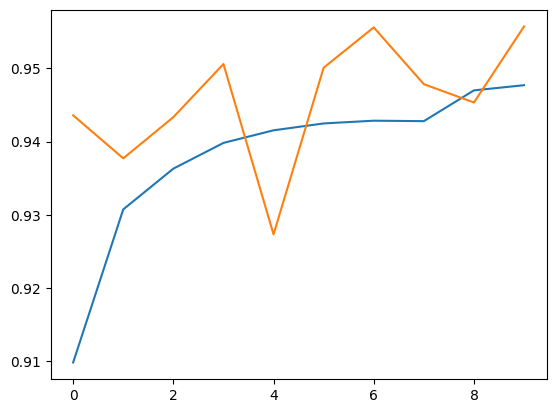

In [40]:
plt.plot(history_keras.history['accuracy'])
plt.plot(history_keras.history['val_accuracy'])

plt.show()

### Take the best weights to ather model

In [41]:
#Copy architecture of the model
model_best = model

#Charge the best weigths to model_best
model_best.load_weights('Best_Model.keras')

#Compile the model
model_best.compile(optimizer=opt,loss='binary_crossentropy',metrics=['accuracy'])

#Evaluate
model_best.evaluate(x_test,y_test)

250/250 ━━━━━━━━━━━━━━━━━━━━ 31s 108ms/step - accuracy: 0.9592 - loss: 0.1678


[0.17328967154026031, 0.9538461565971375]

# Prediction

In [42]:
y_pred = model_best.predict(x_test)

250/250 ━━━━━━━━━━━━━━━━━━━━ 30s 109ms/step


In [43]:
y_pred = y_pred.flatten()

In [44]:
y_pred = np.where(y_pred>0.5,1,0)

# Get F1 Score

In [45]:
from sklearn.metrics import f1_score

In [46]:
#  F1-score
f1 = f1_score(y_test, y_pred,average='binary')

print(f"F1-score: {f1:.2f}")

F1-score: 0.95


# Load test images

In [48]:
import cv2
import os
import numpy as np

# Path to the folder with test images
test_dir ="/kaggle/input/ai-vs-human-generated-dataset/test_data_v2"

# Get the images
imagenes = []
for archivo in os.listdir(test_dir):
    if archivo.endswith('.jpg') or archivo.endswith('.png'):  
        img = cv2.imread(os.path.join(test_dir, archivo))  
        img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))  
        
        
        imagenes.append(img)

imagenes = np.array(imagenes)  
print("Forma del array de imágenes:", imagenes.shape)


Forma del array de imágenes: (5540, 224, 224, 3)


# Prediction in the test data

In [49]:
y_predict_test = model_best.predict(imagenes)


174/174 ━━━━━━━━━━━━━━━━━━━━ 25s 126ms/step


In [50]:
#Change de value to 1 or 0
y_predict_test = np.where(y_predict_test>0.5,1,0)

#Create Dataframe with predictions and images id's
df_final = pd.DataFrame()
df_final['id'] = df_test['id'].values
df_final['label'] = y_predict_test


In [51]:
df_final

,id,label
0,test_data_v2/1a2d9fd3e21b4266aea1f66b30aed157.jpg,0
1,test_data_v2/ab5df8f441fe4fbf9dc9c6baae699dc7.jpg,0
2,test_data_v2/eb364dd2dfe34feda0e52466b7ce7956.jpg,0
3,test_data_v2/f76c2580e9644d85a741a42c6f6b39c0.jpg,0
4,test_data_v2/a16495c578b7494683805484ca27cf9f.jpg,0
...,...,...
5535,test_data_v2/483412064ff74d9d9472d606b65976d9.jpg,0
5536,test_data_v2/c0b49ba4081a4197b422dac7c15aea7f.jpg,1
5537,test_data_v2/01454aaedec140c0a3ca1f48028c41cf.jpg,0
5538,test_data_v2/e9adfea8b67e4791968c4c2bdd8ec343.jpg,0


In [52]:
#Load file sumbission.csv
output = pd.DataFrame({'id': df_final.id, 'label': df_final.label})
output.to_csv('submission_2.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!


In [53]:
value_counts = output['label'].value_counts()
value_counts

label
0    4196
1    1344
Name: count, dtype: int64